In [22]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Imports
from hicrep import hicrepSCC
import matplotlib.pylab as plt
import pandas as pd

# Import custom libraries
import sys
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicvisutils import hic_vis, hic_vis_region
from hicdatautils import import_cool, import_cool_dir, standardize_coolers_bulk, bulk_compare_ref

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Importing the data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/hpmbc_compare'
hpmbc = f'{data_dir}/hpmbc_comp.cool'

hr_hpmbc = import_cool(hpmbc)

In [ ]:
# Importing all sc files
sc_data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

coolers = import_cool_dir(sc_data_dir)

In [ ]:
# Trimming all sc files
    # DO NOT RUN AGAIN UNLESS GENERATING NEW DATA
#standardize_coolers_bulk(coolers, hr_hpmbc, data_dir)

In [ ]:
# Bulk standardization sanity checks
    # Importing data
arc_5350 = f"{sc_data_dir}/arc_pair_5350.cool"
arc_5350_trimmed = f"{data_dir}/arc_pairs/arc_pair_5350_trimmed.cool"

clr_5350 = import_cool(arc_5350)
clr_5350_trimmed = import_cool(arc_5350_trimmed)

    # Visualizing
hic_vis_region(clr_5350, data_type="Normalized", chrom="chr16", cmap="higlass")
hic_vis_region(clr_5350_trimmed, data_type="Normalized", chrom="chr16", cmap="higlass")

    # Checking pixels
pixels = clr_5350.pixels()[:]
st_pixels = clr_5350_trimmed.pixels()[:]
check1 = pixels[pixels['count']==0][pixels["bin2_id"]!=3043]
check2 = st_pixels[st_pixels['count']==0]

print(check1)
print("\n")
print(check2)

In [5]:
# Importing trimmed coolers
trimmed_coolers = import_cool_dir(f'{data_dir}/arc_pairs')

In [6]:
# Bulk scc calculation for chromosome 1

sccs = bulk_compare_ref(trimmed_coolers, hr_hpmbc, 0, -1, False, chr_names=["chr1"])

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

In [7]:
# Verifying bulk approach
arc_681722 = f"{data_dir}/arc_pairs/arc_pair_681722_trimmed.cool"
clr_681722 = import_cool(arc_681722)

print(hicrepSCC(clr_681722, hr_hpmbc, 0, -1, False, ["chr1"]))
print(sccs)

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\


[0.10398466]
{'arc_pair_681722_trimmed': array([0.10398466]), 'arc_pair_625395_trimmed': array([0.08069554]), 'arc_pair_92436_trimmed': array([0.07935623]), 'arc_pair_120514_trimmed': array([0.09330023]), 'arc_pair_734972_trimmed': array([0.04067589]), 'arc_pair_672302_trimmed': array([0.1401402]), 'arc_pair_523348_trimmed': array([0.08863198]), 'arc_pair_24162_trimmed': array([0.07876254]), 'arc_pair_715688_trimmed': array([0.07828666]), 'arc_pair_350644_trimmed': array([0.0825596]), 'arc_pair_578971_trimmed': array([0.1317636]), 'arc_pair_229477_trimmed': array([0.07701844]), 'arc_pair_613159_trimmed': array([0.08227117]), 'arc_pair_574451_trimmed': array([0.08422254]), 'arc_pair_135667_trimmed': array([0.08712707]), 'arc_pair_157456_trimmed': array([0.08437228]), 'arc_pair_113022_trimmed': array([0.09400715]), 'arc_pair_271285_trimmed': array([0.08102717]), 'arc_pair_504729_trimmed': array([0.09594984]), 'arc_pair_178319_trimmed': array([0.12995969]), 'arc_pair_345537_trimmed': arra

In [19]:
# Converting chr1 data to DataFrame
out_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/hpmbc_compare/scc'

chr1_arc_hpmbc = pd.DataFrame.from_dict(sccs, orient='index', columns=["HPMBC Chr1 SCC"])
chr1_arc_hpmbc.head()

,HPMBC Chr1 SCC
arc_pair_681722_trimmed,0.103985
arc_pair_625395_trimmed,0.080696
arc_pair_92436_trimmed,0.079356
arc_pair_120514_trimmed,0.093300
arc_pair_734972_trimmed,0.040676


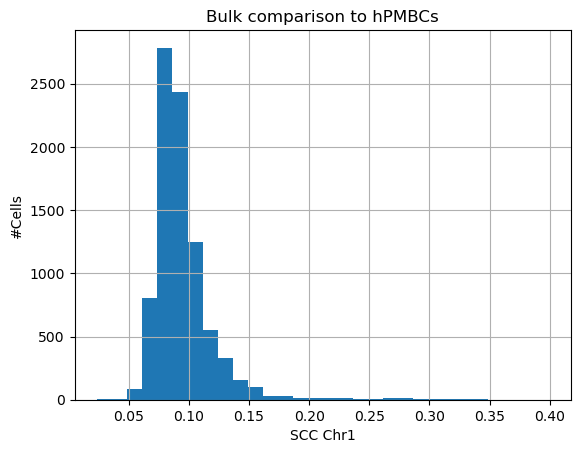

In [27]:
# Plot data to histogram
chr1_arc_hpmbc.hist(bins=30)

plt.xlabel("SCC Chr1")
plt.ylabel("#Cells")
plt.title("Bulk comparison to hPMBCs")

plt.show()

In [ ]:
from random import randint

print("work sad :(")

sadness = randint(0, 11)

if sadness <= 3:
    print("but its not that sad")
elif sadness > 3 and sadness <= 7:
    print("and its not fun")
else:
    print("it is extremely sadenning actually :<")

work sad :(
5
and its not fun
